# ChemicalMotifIdentifier

This is a quick tutorial on:
1. Analytically obtaining a pattern inventory for a ternary system (CrCoNi) in the fcc crystal structure. 
2. Obtaining the pattern inventory with ML and creating a physically constrained embedding space from which we can compute dissimilarities between motifs. 
3. Chemical motif identification in atomistic data and computing dissimilarity between motifs.

In [1]:
%%capture 
! pip install gdown

! pip install chemicalmotifidentifier

! pip install rich

In [1]:
%%capture
from polya import Polya
from rich import print
from sympy import init_printing, symbols  # For latex formatting
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

%matplotlib inline

from _frameworks import INPUT_GDOWN_LINK

# Downloading neceassry inputs (model weights, dump files, ...)
import gdown

# os.makedirs("data/", exist_ok=True)
# gdown.download_folder(INPUT_GDOWN_LINK, output="data/", quiet=True)

## 1. Ternary system pattern inventory

In [2]:
init_printing()

pl = Polya(graph_name="fcc")

ntypes = 3
p_g, nms = pl.get_gt(ntypes=ntypes)

# Replacing t1, t2 and t3 with Cr, Co, Ni.
p_g = p_g.subs(
    {
        symbols("t1"): symbols("Cr"),
        symbols("t2"): symbols("Co"),
        symbols("t3"): symbols("Ni"),
    }
)

print(
    "The pattern inventory for the fcc first coordination polyhedron of the CrCoNi system is given by: \n"
)

p_g

The pattern inventory for the fcc first coordination polyhedron of the CrCoNi system is given by:

In [3]:
print(
    f"\n We have a total of {nms} distinct coordination polyhedron, which in turns yield {nms*ntypes} distinct local chemical motifs. "
)

We have a total of 12111 distinct coordination polyhedron, which in turns yield 36333 distinct local chemical 
motifs.

## 2. Model expressivity on the fcc ternary synthetic dataset and physically constrained embedding space

In [4]:
%%capture 
from _frameworks import SyntheticChemicalMotifIdentifier

eca = SyntheticChemicalMotifIdentifier(crystal_structure="fcc")
df = eca.predict(
        root="data/synthetic/fcc_graph_datasets/",
        skeleton_graph_path="data/inputs_doi-10.48550-arXiv.2311.01545/fcc_1nn.pt",
        atom_types_paths=[
            "data/inputs_doi-10.48550-arXiv.2311.01545/fcc_nelement3_generators.pt"
        ],
        nelement=3,
    )
os.makedirs("data/synthetic/outputs/", exist_ok=True)
df.to_pickle("data/synthetic/outputs/df_fcc.pkl")

In [5]:
# Obtaining the ML pattern inventory
df = pd.read_pickle("data/synthetic/outputs/df_fcc.pkl")

shell_concentrations, counts = (
    np.array(list(df.shell_concentration)),
    np.array(list(df.counts)),
)
unique_concentrations, counts = np.unique(
    shell_concentrations, axis=0, return_counts=True
)

pattern = {
    tuple(unique_concentrations[i]): counts[i]
    for i in range(len(unique_concentrations))
}
print("The machine learning pattern inventory is given by:")
print(pattern)
print(f"We have a total of {np.sum(counts)} distinct 1CP.")

The machine learning pattern inventory is given by:

{
    (np.float64(0.0), np.float64(0.0), np.float64(12.0)): np.int64(1),
    (np.float64(0.0), np.float64(1.0), np.float64(11.0)): np.int64(1),
    (np.float64(0.0), np.float64(2.0), np.float64(10.0)): np.int64(4),
    (np.float64(0.0), np.float64(3.0), np.float64(9.0)): np.int64(9),
    (np.float64(0.0), np.float64(4.0), np.float64(8.0)): np.int64(18),
    (np.float64(0.0), np.float64(5.0), np.float64(7.0)): np.int64(24),
    (np.float64(0.0), np.float64(6.0), np.float64(6.0)): np.int64(30),
    (np.float64(0.0), np.float64(7.0), np.float64(5.0)): np.int64(24),
    (np.float64(0.0), np.float64(8.0), np.float64(4.0)): np.int64(18),
    (np.float64(0.0), np.float64(9.0), np.float64(3.0)): np.int64(9),
    (np.float64(0.0), np.float64(10.0), np.float64(2.0)): np.int64(4),
    (np.float64(0.0), np.float64(11.0), np.float64(1.0)): np.int64(1),
    (np.float64(0.0), np.float64(12.0), np.float64(0.0)): np.int64(1),
    (np.float64(1.0), np.float64(0.0), np.float64(11.0)): np.int64(1),
    (np.float64(1.0), np.float64(1.0), np.float64(10.0)): np.int64(4),
    (np.float64(1.0), np.float64(2.0), np.float64(9.0)): np.int64(18),
    (np.float64(1.0), np.float64(3.0), np.float64(8.0)): np.int64(47),
    (np.float64(1.0), np.float64(4.0), np.float64(7.0)): np.int64(92),
    (np.float64(1.0), np.float64(5.0), np.float64(6.0)): np.int64(126),
    (np.float64(1.0), np.float64(6.0), np.float64(5.0)): np.int64(126),
    (np.float64(1.0), np.float64(7.0), np.float64(4.0)): np.int64(92),
    (np.float64(1.0), np.float64(8.0), np.float64(3.0)): np.int64(47),
    (np.float64(1.0), np.float64(9.0), np.float64(2.0)): np.int64(18),
    (np.float64(1.0), np.float64(10.0), np.float64(1.0)): np.int64(4),
    (np.float64(1.0), np.float64(11.0), np.float64(0.0)): np.int64(1),
    (np.float64(2.0), np.float64(0.0), np.float64(10.0)): np.int64(4),
    (np.float64(2.0), np.float64(1.0), np.float64(9.0)): np.int64(18),
    (np.float64(2.0), np.float64(2.0), np.float64(8.0)): np.int64(76),
    (np.float64(2.0), np.float64(3.0), np.float64(7.0)): np.int64(182),
    (np.float64(2.0), np.float64(4.0), np.float64(6.0)): np.int64(318),
    (np.float64(2.0), np.float64(5.0), np.float64(5.0)): np.int64(372),
    (np.float64(2.0), np.float64(6.0), np.float64(4.0)): np.int64(318),
    (np.float64(2.0), np.float64(7.0), np.float64(3.0)): np.int64(182),
    (np.float64(2.0), np.float64(8.0), np.float64(2.0)): np.int64(76),
    (np.float64(2.0), np.float64(9.0), np.float64(1.0)): np.int64(18),
    (np.float64(2.0), np.float64(10.0), np.float64(0.0)): np.int64(4),
    (np.float64(3.0), np.float64(0.0), np.float64(9.0)): np.int64(9),
    (np.float64(3.0), np.float64(1.0), np.float64(8.0)): np.int64(47),
    (np.float64(3.0), np.float64(2.0), np.float64(7.0)): np.int64(182),
    (np.float64(3.0), np.float64(3.0), np.float64(6.0)): np.int64(408),
    (np.float64(3.0), np.float64(4.0), np.float64(5.0)): np.int64(606),
    (np.float64(3.0), np.float64(5.0), np.float64(4.0)): np.int64(606),
    (np.float64(3.0), np.float64(6.0), np.float64(3.0)): np.int64(408),
    (np.float64(3.0), np.float64(7.0), np.float64(2.0)): np.int64(182),
    (np.float64(3.0), np.float64(8.0), np.float64(1.0)): np.int64(47),
    (np.float64(3.0), np.float64(9.0), np.float64(0.0)): np.int64(9),
    (np.float64(4.0), np.float64(0.0), np.float64(8.0)): np.int64(18),
    (np.float64(4.0), np.float64(1.0), np.float64(7.0)): np.int64(92),
    (np.float64(4.0), np.float64(2.0), np.float64(6.0)): np.int64(318),
    (np.float64(4.0), np.float64(3.0), np.float64(5.0)): np.int64(606),
    (np.float64(4.0), np.float64(4.0), np.float64(4.0)): np.int64(768),
    (np.float64(4.0), np.float64(5.0), np.float64(3.0)): np.int64(606),
    (np.float64(4.0), np.float64(6.0), np.float64(2.0)): np.int64(318),
    (np.float64(4.0), np.float64(7.0), np.float64(1.0)): np.int64(92),
    (np.float64(4.0), np.float64(8.0), np.float64(0.0)): np.int64(18),
    (np.float64(5.0), np.float64(0.0), np.float64(7.0)): np.int64(24),
    (np.

We have a total of 12111 distinct 1CP.

## 3. Chemical motif identification in atomistic data

In [7]:
%%capture 
from _frameworks import MonteCarloChemicalMotifIdentifier

dump_files = [
    f"data/inputs_doi-10.48550-arXiv.2311.01545/dumps/ordered_relaxation_20_{i}_300K.dump"
    for i in range(1, 5 + 1)
]

eca = MonteCarloChemicalMotifIdentifier(crystal_structure="fcc")
df = eca.predict(root="data/mc/outputs/eca_id/300K/", dump_file=dump_files)
kl = eca.get_kl(df)
df.to_pickle("data/mc/outputs/eca_id/300K/df_microstates.pkl")

Note here that edges will be snap back to their closest perfect ideal direction. 

Alternatively, you can use the ``_frameworks.PTMMotifIdentifier`` to only identify motifs in specific crystal structures and for correcting their distortions.

Let's compute the dissimilarity between motif $\mathcal{M}_0$ and $\mathcal{M}_1$ shown below: 

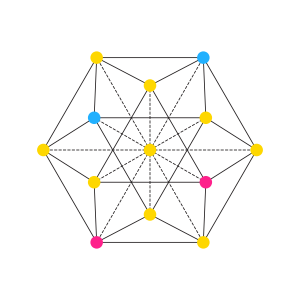

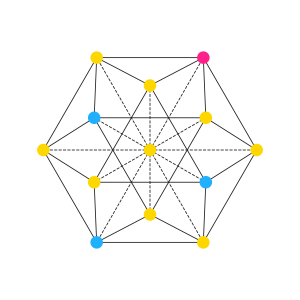

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


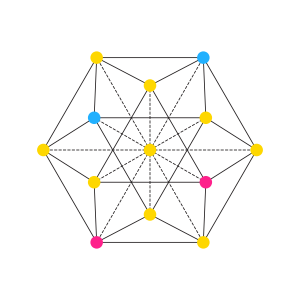

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


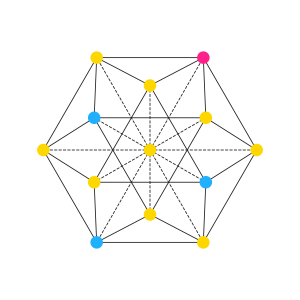

In [9]:
%matplotlib inline

from chemicalmotifidentifier import Plot
plot = Plot(
    structure="fcc",
    graph_folder="data/inputs_doi-10.48550-arXiv.2311.01545/graph_plot_templates",
)
plot.set_colors(np.array(["#FED700", "#21B0FE", "#FE218B"]))
plot.set_node_size(4)
plot.set_width(0.2)

for i in [0, 1]:
    df_row = df.iloc[i]

    types_with_central_atom = np.concatenate(
        ([df_row.central_atom_type], np.array(list(df_row.shell_atomic_types)))
    )

    fig, ax = plt.subplots(figsize=(1, 1))
    plot.plot_ms(new_atom_types=types_with_central_atom)
    plt.show()

In [10]:
from chemicalmotifidentifier import Dissimilarity

phys_emb_i = np.concatenate(([df.iloc[0].central_atom_type], df.iloc[0].shell_phys_emb))
phys_emb_j = np.concatenate(([df.iloc[1].central_atom_type], df.iloc[1].shell_phys_emb))

(
    central_atom_dissim,
    concentration_dissim,
    structural_dissim,
) = Dissimilarity().get_separate_dissimilarities(3, phys_emb_j, phys_emb_i)

weights = np.array([12.0, 24.0, 24.0])
weights *= 1 / np.sum(weights)
d_ij = (
    weights[0] * central_atom_dissim
    + weights[1] * concentration_dissim / 12
    + weights[2] * structural_dissim
)


print(f"The dissimilarity between these two motifs is: {d_ij[0]:.2f}.\n\nBefore weighthing based on the number of bonds of each structure, they have a central atom dissimilarity of {central_atom_dissim[0]:.2f} since their central atom atomic types are the same. Their chemical composition dissimilarity is of {concentration_dissim[0]:.2f}/12 because we lost one red and gained one blue atom. And their structural dissimilarity is of {structural_dissim[0]:.2f}.")

The dissimilarity between these two motifs is: 0.09.

Before weighthing based on the number of bonds of each structure, they have a central atom dissimilarity of 0.00 
since their central atom atomic types are the same. Their chemical composition dissimilarity is of 1.00/12 because 
we lost one red and gained one blue atom. And their structural dissimilarity is of 0.15.

Inference: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [01:23<00:00,  2.61s/it]
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


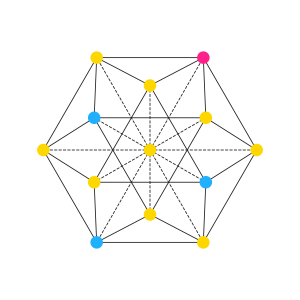

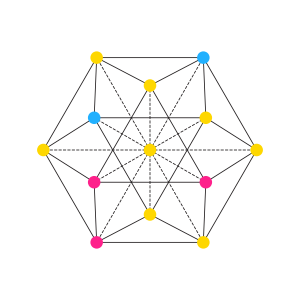

In [14]:
from _frameworks import MonteCarloChemicalMotifIdentifier

dump_files = [
    f"data/inputs_doi-10.48550-arXiv.2311.01545/dumps_own/ordered_relaxation_20_{i}_300K_shuffled.dump"
    for i in range(1, 2 + 1)
]

# need to replace the data/synthetic/outputs/df_fcc.pkl to data/inputs_doi-10.48550-arXiv.2311.01545/df_{self.crystal_structure}.pkl
eca = MonteCarloChemicalMotifIdentifier(crystal_structure="fcc")
df = eca.predict(root="data/mc/outputs/eca_id/300K/", dump_file=dump_files)
kl = eca.get_kl(df)
df.to_pickle("data/mc/outputs/eca_id/300K/df_microstates.pkl")

from chemicalmotifidentifier import Plot
plot = Plot(
    structure="fcc",
    graph_folder="data/inputs_doi-10.48550-arXiv.2311.01545/graph_plot_templates",
)
plot.set_colors(np.array(["#FED700", "#21B0FE", "#FE218B"]))
plot.set_node_size(4)
plot.set_width(0.2)

for i in [0, 1]:
    df_row = df.iloc[i]

    types_with_central_atom = np.concatenate(
        ([df_row.central_atom_type], np.array(list(df_row.shell_atomic_types)))
    )

    fig, ax = plt.subplots(figsize=(1, 1))
    plot.plot_ms(new_atom_types=types_with_central_atom)
    plt.savefig(f"data/inputs_doi-10.48550-arXiv.2311.01545/graph_plot_templates/result_{i}.png")